<a href="https://colab.research.google.com/github/Slautin/2026_photoKPFM/blob/main/2_photoKPFM_ternary_PEA-BDA-FAPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# photoKPFM experiment


System: PEA-BDA-FABI



**J. Marshall, B. Slautin, M. Ahmadi, S. Kalinin**

In [ ]:
!pip install aespm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.0/161.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but yo

In [ ]:
!pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json

import aespm.tools as at

In [ ]:
#experimental data 1
!gdown https://drive.google.com/file/d/1UYVvqHTiRvyhVq-f4inGsYYgXZW-1C9i/view?usp=sharing --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1UYVvqHTiRvyhVq-f4inGsYYgXZW-1C9i
To: /content/20260311_PEA_BDA_FAPI_3_3.h5
100% 2.50M/2.50M [00:00<00:00, 70.1MB/s]


In [ ]:
#!unzip PEA_FAPI_2

In [ ]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [ ]:
#@title gp model
from botorch.models import SingleTaskGP
from gpytorch.kernels import ScaleKernel, RBFKernel, MaternKernel
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
import torch
import gpytorch

from gpytorch.priors import GammaPrior, SmoothedBoxPrior
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.kernels import ScaleKernel, RBFKernel, MaternKernel
from gpytorch.mlls import ExactMarginalLogLikelihood

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.models.transforms import Normalize, Standardize
from botorch.acquisition.analytic import LogExpectedImprovement, ExpectedImprovement, UpperConfidenceBound

tt = torch.tensor


def gp_prediction(X_train,
                  y_train,
                  X,
                  lengthscale_prior= SmoothedBoxPrior(.05, .5, sigma=0.02),
                  noise_prior = GammaPrior(1.5, 1.5),
                  outputscale_prior = GammaPrior(2.0, 0.1),
                  input_transform=None,#Normalize(d=d),          # maps each dim to [0,1]
                  outcome_transform=None
                  ):
    X_train = torch.as_tensor(X_train, dtype=torch.double).reshape(len(X_train), -1)
    y_train = torch.as_tensor(y_train, dtype=torch.double).reshape(-1, 1)
    X_torch = torch.as_tensor(X, dtype=torch.double).reshape(len(X), -1)

    gp_model = make_gp_model(X_train, y_train,
                             lengthscale_prior= lengthscale_prior,
                             noise_prior = noise_prior,
                             outputscale_prior = outputscale_prior,
                             input_transform = input_transform,#Normalize(d=d),          # maps each dim to [0,1]
                             outcome_transform = outcome_transform#Standardize(m=1),
                            )

    mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
    fit_gpytorch_mll(mll)

#     print("Learned noise:", gp_model.likelihood.noise.item())
#     print("Lengthscale:", gp_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy())
#     print("Outputscale:", gp_model.covar_module.outputscale.item())


    gp_model.eval()
    with torch.no_grad():
        posterior = gp_model.posterior(X_torch)
        mean = posterior.mean.squeeze(-1)
        var = posterior.variance.squeeze(-1)

    return gp_model, mean.numpy(), var.numpy()

def make_gp_model(X_train, y_train,
                  lengthscale_prior= SmoothedBoxPrior(.05, .5, sigma=0.02),
                  noise_prior = GammaPrior(1.5, 1.5),
                  outputscale_prior = GammaPrior(2.0, 0.1),
                  input_transform=None,#Normalize(d=d),          # maps each dim to [0,1]
                  outcome_transform=None#Standardize(m=1),
                  ):
    likelihood = GaussianLikelihood()
    covar_module = ScaleKernel(MaternKernel(
                                         n=1.5,
                                         lengthscale_prior=lengthscale_prior,
                                         noise_prior = noise_prior,
                                         ard_num_dims=X_train.shape[1],
                                         ),
                               outputscale_prior = outputscale_prior
                               )
    model = SingleTaskGP(X_train, y_train,
                         covar_module=covar_module,
                         input_transform = input_transform,
                         outcome_transform=outcome_transform,
                         likelihood=likelihood)

    return model

In [ ]:
def generate_plate_compositions(step=8, total=100, plate_size=96):
    """
    Returns
    -------
    arr : np.ndarray of shape (96, 3)
        Each row is [PEA, BDA, FA] in plate order:
        A1, B1, ..., H1, A2, ..., H12
    """
    n = total // step
    comps = []

    # generate unique ternary compositions
    for k in range(n + 1):
        pea = total - step * k
        for bda in range(k, -1, -1):
            fa = k - bda
            comps.append([pea, step * bda, step * fa])

    comps = np.array(comps, dtype=int)

    # pad to 96 wells if needed
    if len(comps) < plate_size:
        extra = plate_size - len(comps)
        comps = np.vstack([comps, comps[-extra:]])
    else:
        comps = comps[:plate_size]

    return comps

def barycentric_to_cartesian(x, y, z):
    A = np.array([1, 0])
    B = np.array([0, 0])
    C = np.array([0.5, np.sqrt(3)/2])
    return np.outer(x, A) + np.outer(y, B) + np.outer(z, C)




In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian1(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def recalculate_y_train_from_hist(
    res_dict,
    crop=10,
    bins=30,
    hist_range=(-2.5, -0.5),
    use_abs=False,
    fallback='mean'
):
    """
    Recalculate y_train from dark/light image stacks using the same logic
    as in the histogram figure: Gaussian fit to histogram centers.

    Parameters
    ----------
    res_dict : dict
        Dictionary containing at least 'dark_data' and 'light_data'.
    crop : int
        Number of pixels cropped from each border.
    bins : int
        Number of histogram bins.
    hist_range : tuple
        Histogram range, e.g. (-2.5, -0.5).
    use_abs : bool
        If True, return abs(mu_light - mu_dark).
        If False, return signed (mu_light - mu_dark).
    fallback : str
        What to use if Gaussian fit fails:
        - 'mean' : use mean(light) - mean(dark)
        - 'median' : use median(light) - median(dark)
        - 'nan' : assign np.nan

    Returns
    -------
    y_new : np.ndarray
        Recalculated y_train values.
    mu_dark_all : np.ndarray
        Fitted dark centers.
    mu_light_all : np.ndarray
        Fitted light centers.
    """
    dark_data = res_dict['dark_data']
    light_data = res_dict['light_data']

    n = len(dark_data)

    y_new = np.full(n, np.nan, dtype=float)
    mu_dark_all = np.full(n, np.nan, dtype=float)
    mu_light_all = np.full(n, np.nan, dtype=float)

    for i in range(n):
        dark_vals = dark_data[i][crop:-crop, crop:-crop].ravel()
        light_vals = light_data[i][crop:-crop, crop:-crop].ravel()

        # histogram for dark
        counts_d, bin_e_d = np.histogram(dark_vals, bins=bins, range=hist_range)
        bin_c_d = 0.5 * (bin_e_d[:-1] + bin_e_d[1:])

        # histogram for light
        counts_l, bin_e_l = np.histogram(light_vals, bins=bins, range=hist_range)
        bin_c_l = 0.5 * (bin_e_l[:-1] + bin_e_l[1:])

        fit_ok = True

        try:
            p0_d = [counts_d.max(), np.mean(dark_vals), np.std(dark_vals)]
            opt_d, _ = curve_fit(gaussian1, bin_c_d, counts_d, p0=p0_d, maxfev=5000)
            mu_d = opt_d[1]
        except:
            fit_ok = False

        try:
            p0_l = [counts_l.max(), np.mean(light_vals), np.std(light_vals)]
            opt_l, _ = curve_fit(gaussian1, bin_c_l, counts_l, p0=p0_l, maxfev=5000)
            mu_l = opt_l[1]
        except:
            fit_ok = False

        if fit_ok:
            val = mu_l - mu_d
            mu_dark_all[i] = mu_d
            mu_light_all[i] = mu_l
        else:
            if fallback == 'mean':
                mu_d = np.mean(dark_vals)
                mu_l = np.mean(light_vals)
                val = mu_l - mu_d
                mu_dark_all[i] = mu_d
                mu_light_all[i] = mu_l
            elif fallback == 'median':
                mu_d = np.median(dark_vals)
                mu_l = np.median(light_vals)
                val = mu_l - mu_d
                mu_dark_all[i] = mu_d
                mu_light_all[i] = mu_l
            elif fallback == 'nan':
                val = np.nan
            else:
                raise ValueError("fallback must be 'mean', 'median', or 'nan'")

        y_new[i] = abs(val) if use_abs else val

    return y_new, mu_dark_all, mu_light_all

In [ ]:
file_h5 = r"/content/20260311_PEA_BDA_FAPI_3_3.h5"

In [ ]:
#load results
res_dict = load_hdf5_to_dict(file_h5)

In [ ]:
res_dict.keys()

dict_keys(['X', 'X_train', 'coord_array', 'dark_data', 'dark_fn', 'idx', 'light_data', 'light_fn', 'y_train'])

In [ ]:
print('Measured droplets number (0-95): ', res_dict['idx'])

Measured droplets number (0-95):  [ 0 40 78 90  1 45 35 81 87 78  7  0 16 78  0 46  6 78  0]


In [ ]:
dark_files = res_dict['dark_fn']
light_files = res_dict['light_fn']

X_train = res_dict['X_train']
X_train_int = (X_train*95).astype(int)
y_train = res_dict['y_train']
X = res_dict['X']

dark_data = res_dict['dark_data']
light_data = res_dict['light_data']
light_files = res_dict['light_fn']
idx = res_dict['idx']

coord_array = res_dict['coord_array']

y_train_new, mu_dark, mu_light = recalculate_y_train_from_hist(
    res_dict,
    crop=10,
    bins=30,
    hist_range=(-2.5, -0.5),
    use_abs=False
)

In [ ]:
y_train, y_train_new

(array([ 0.0912807 ,  0.10477328, -0.00258493,  0.09330809,  0.13382137,
         0.01107371,  0.11596143, -0.02901626, -0.00326717,  0.11809742,
         0.03686583,  0.15503132,  0.01532829,  0.03634226,  0.1192627 ,
         0.01208889,  0.12986207, -0.00908351,  0.22157609]),
 array([ 7.18829966e-02,  6.06511787e-02,  3.03855297e-04,  9.01658598e-02,
         1.35336563e-01, -4.90073357e-03,  1.04260427e-01, -3.24012249e-02,
        -7.00965864e-04,  1.11635973e-01,  3.68657321e-02,  1.47285189e-01,
         4.42748108e-03,  2.42928702e-02,  1.04051346e-01,  1.12850378e-02,
         1.31100692e-01, -5.17676241e-05,  2.15448966e-01]))

In [ ]:
gp, _mean, _var = gp_prediction(tt(X_train),
                                tt(y_train_new),
                                tt(X),
                                lengthscale_prior= SmoothedBoxPrior(.01, 1, sigma=0.02),
                                noise_prior = None,#GammaPrior(1.5, 1.5),
                                outputscale_prior = None,#GammaPrior(2.0, 0.1),
                                input_transform=Normalize(d=2),)          # maps each dim to [0,1]
                                #outcome_transform=Standardize(m=1))

In [ ]:
posterior = gp.posterior(torch.tensor(X))

mean = posterior.mean.detach().numpy().ravel()
std = posterior.variance.sqrt().detach().numpy().ravel()

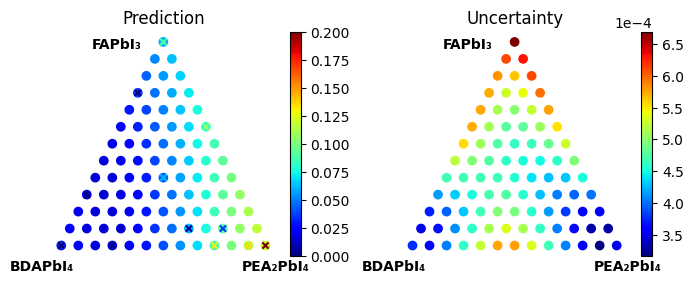

In [ ]:
import matplotlib.ticker as ticker

def pred_visualization(X, pred, X_train, y_train, iter = None):


    fig, ax = plt.subplots(1, 2, figsize=(7,3))

    im0 = ax[0].scatter(*X.T, c = pred[0], vmin=0, vmax=0.2, cmap='jet')
    plt.colorbar(im0)
    ax[0].set_title('Prediction')

    im1 = ax[1].scatter(*X.T, c = pred[1], cmap='jet')


    cbar = plt.colorbar(im1, ax=ax[1])
    cbar.formatter = ticker.ScalarFormatter(useMathText=False)
    cbar.formatter.set_scientific(True)
    cbar.formatter.set_powerlimits((0, 0))  # always use 1e-n notation
    cbar.update_ticks()

    ax[1].set_title("Uncertainty")


    ax[0].scatter(*X_train.T, marker='x', c = y_train, vmin=0, vmax=0.2, cmap='jet', s=20)# c='w', s=20)

    plt.tight_layout()

    return fig, ax

fig, ax = pred_visualization(X, np.array([_mean, _var]), X_train[1:], y_train_new[1:], iter = None)

for _ in ax:
  _.text(-.05, -0.1, "BDAPbI₄", ha='center', fontsize=10, fontweight='bold')
  _.text(1.05, -0.1, "PEA₂PbI₄", ha='center', fontsize=10, fontweight='bold')
  _.text(0.3, np.sqrt(3)/2-0.06, "FAPbI₃", ha='center', fontsize=10, fontweight='bold')
  _.axis('off')

fig.savefig("figs_uncertainty.jpg", dpi=300, bbox_inches='tight')

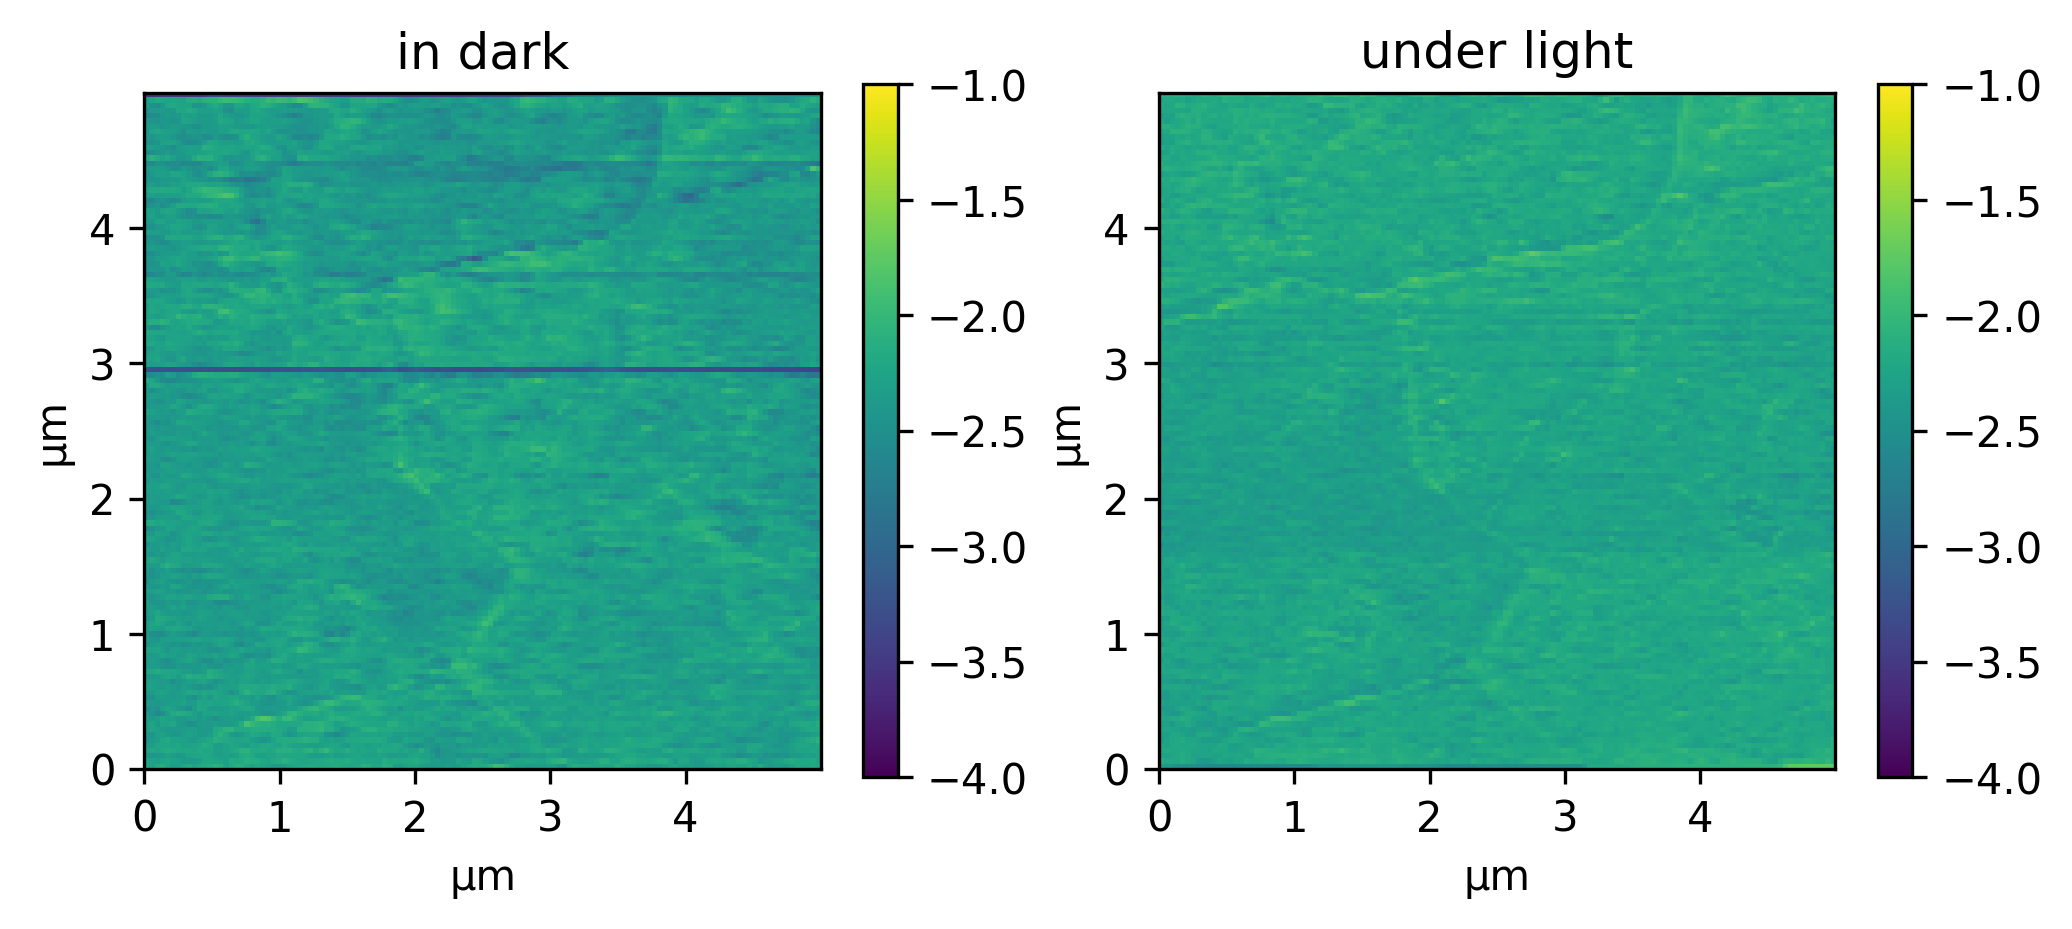

In [ ]:
ii = 0

range_min = -4
range_max = -1

fig, ax = plt.subplots(1, 2, figsize=(8, 3), dpi=300)

im0 = ax[0].imshow(dark_data[ii], extent=(0,5,0,5), origin='lower', vmin = range_min, vmax = range_max)
plt.colorbar(im0)

im1 =ax[1].imshow(light_data[ii], extent=(0,5,0,5), origin='lower', vmin = range_min, vmax = range_max)
plt.colorbar(im1)

ax[0].set_title('in dark')
ax[1].set_title('under light')

for ax_ in ax:
  ax_.set_xticks([0,1,2,3,4])
  ax_.set_yticks([0,1,2,3,4])
  ax_.set_xlabel('µm')
  ax_.set_ylabel('µm')

In [ ]:
from scipy.optimize import curve_fit

def gaussian1(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

Text(0, 0.5, 'Count')

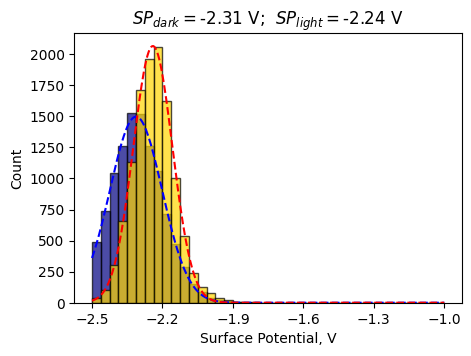

In [ ]:
#select idx
ii = 0

#you can change the range for the hist here, if needed
range_min = -2.5
range_max = -1

fig = plt.figure(figsize=(5,3.5))

counts_d, bin_e_d, _ = plt.hist(dark_data[ii][10:-10, 10:-10].flatten(), color='navy', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))

bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2
opt_d, cov_d = curve_fit(gaussian1, bin_c_d, counts_d)

x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 300)
y_fit = gaussian1(x_fit, *opt_d)
plt.plot(x_fit, y_fit, '--', color='blue')

counts_l, bin_e_l, _ = plt.hist(light_data[ii][10:-10, 10:-10].flatten(), color='gold', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))

bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2
opt, cov = curve_fit(gaussian1, bin_c_l, counts_l)

x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 300)
y_fit = gaussian1(x_fit, *opt)
plt.plot(x_fit, y_fit, '--', color='r')

plt.title('$SP_{dark} = $'+f'{round(opt_d[1],2)} V;'+
          '  $SP_{light} = $'+f'{round(opt[1],2)} V'
)

plt.xticks(np.linspace(range_min, range_max, 6))

plt.xlabel('Surface Potential, V')
plt.ylabel('Count')

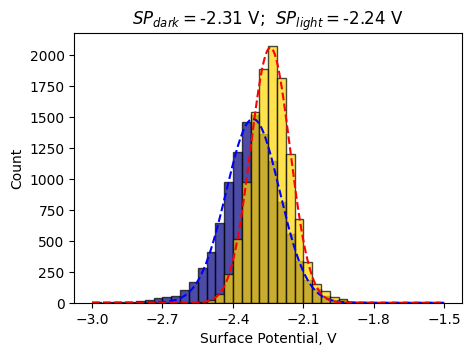

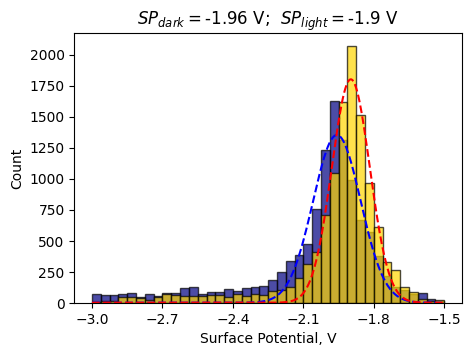

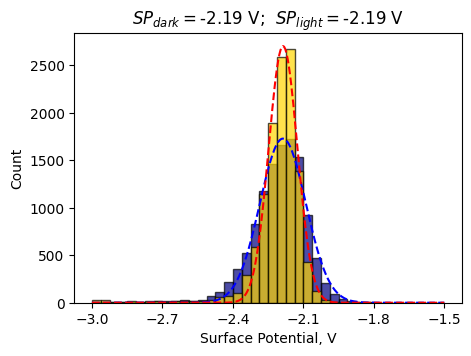

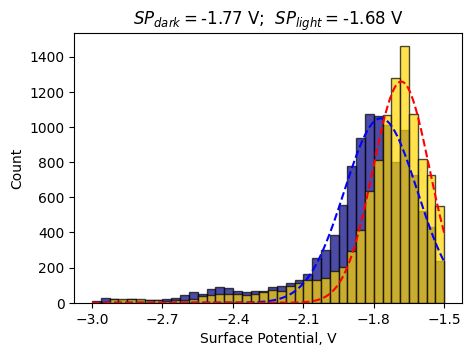

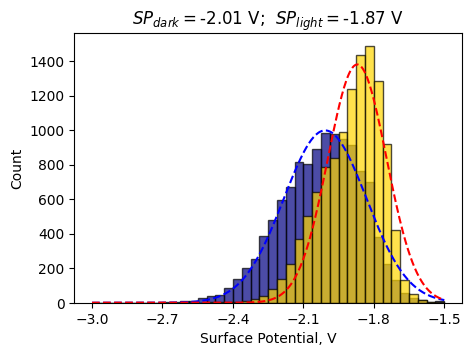

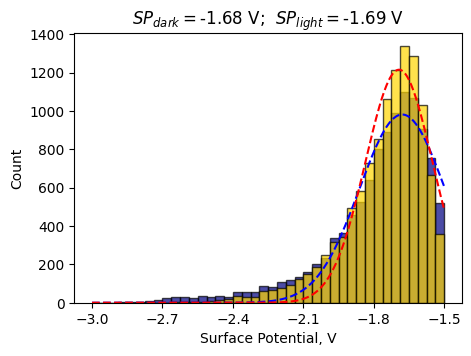

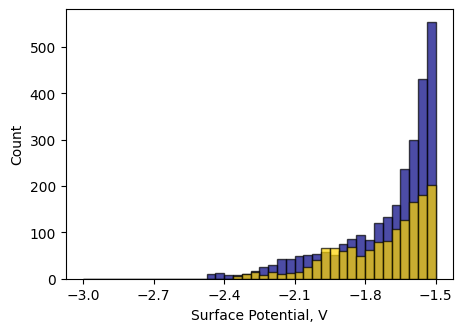

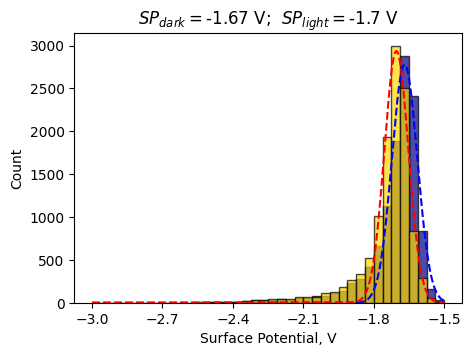

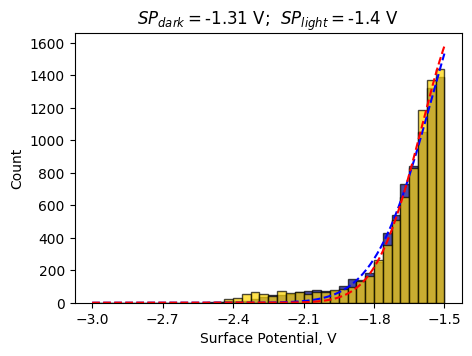

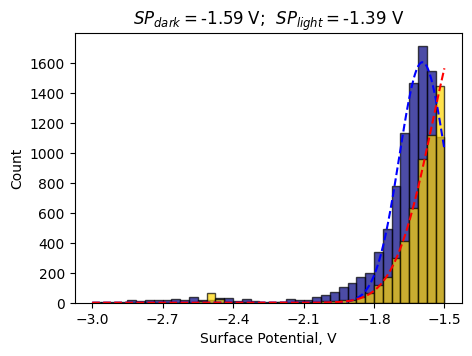

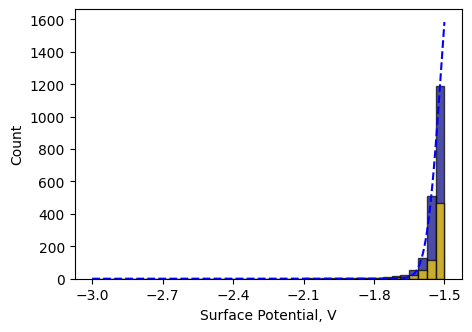

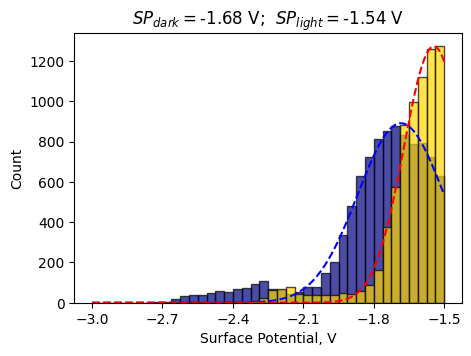

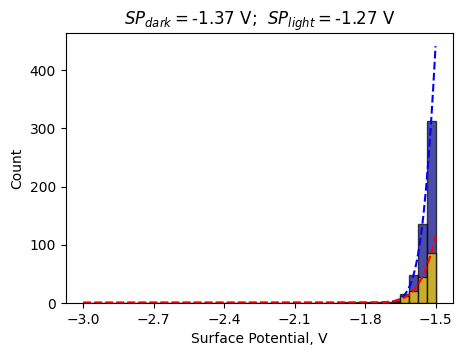

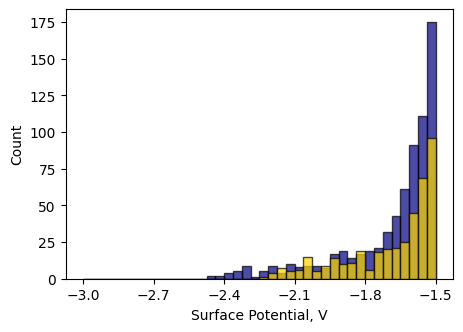

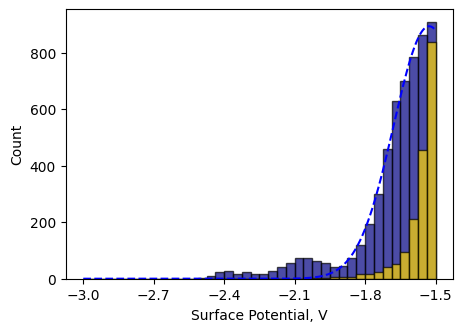

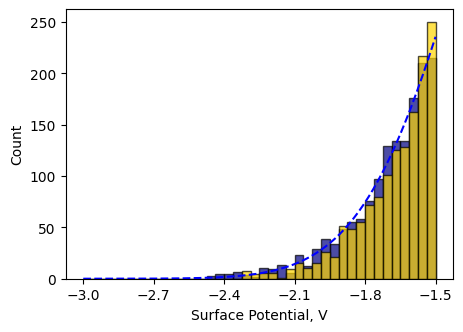

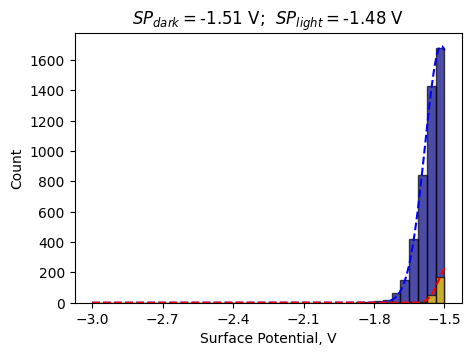

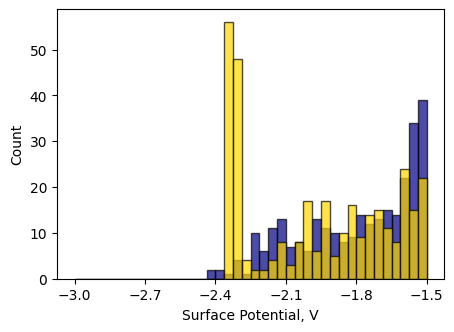

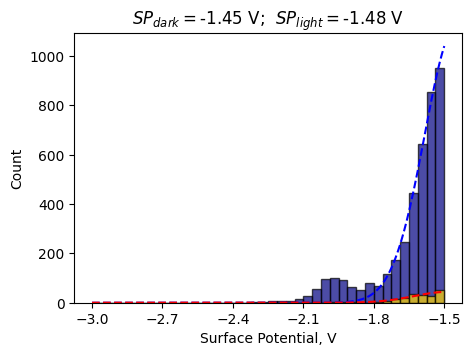

In [ ]:
#select idx
ii = 4

#you can change the range for the hist here, if needed
range_min = -3
range_max = -1.5

for ii in range(len(dark_data)):

  fig = plt.figure(figsize=(5,3.5))

  counts_d, bin_e_d, _ = plt.hist(dark_data[ii][10:-10, 10:-10].flatten(), color='navy', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))
  counts_l, bin_e_l, _ = plt.hist(light_data[ii][10:-10, 10:-10].flatten(), color='gold', edgecolor = 'black', alpha=0.7, bins=40, range=(range_min,range_max))



  try:
    bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2
    opt_d, cov_d = curve_fit(gaussian1, bin_c_d, counts_d)

    x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 300)
    y_fit = gaussian1(x_fit, *opt_d)
    plt.plot(x_fit, y_fit, '--', color='blue')

    bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2
    opt, cov = curve_fit(gaussian1, bin_c_l, counts_l)

    x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 300)
    y_fit = gaussian1(x_fit, *opt)
    plt.plot(x_fit, y_fit, '--', color='r')


    plt.title('$SP_{dark} = $'+f'{round(opt_d[1],2)} V;'+
              '  $SP_{light} = $'+f'{round(opt[1],2)} V'
    )
  except:
    pass

  plt.xticks(np.linspace(range_min, range_max, 6))

  plt.xlabel('Surface Potential, V')
  plt.ylabel('Count')

In [ ]:
#@title uncertainty estimation (within-droplet sigma + repeated compositions)

# Two error sources, treated separately:
#
# 1) err_within  = sqrt(sigma_dark**2 + sigma_light**2)
#    sigma = std of the gaussian fitted to the SP histogram of each scan
#    -> within-droplet spatial heterogeneity (available for EVERY droplet)
#
# 2) err_between = std(dSP over repeats, ddof=1)
#    -> droplet-to-droplet diversity for compositions measured more than
#       once (end members). This is the physically relevant error there,
#       since it captures sample variability the single-scan sigma cannot.
#
# Final per-droplet error:
#   err_dsp = err_between  if the composition was measured >1 times
#           = err_within   for single-measured compositions
#
# Also reported: sem = err_between/sqrt(n_rep) — the standard error of the
# composition-mean dSP, if you prefer to plot the mean value per composition.

crop = 10
bins = 30
hist_range = (-2.7, -0.1)


def fit_mu_sigma(vals, hist_range, bins=30):
    counts, bin_e = np.histogram(vals, bins=bins, range=hist_range)
    bin_c = 0.5 * (bin_e[:-1] + bin_e[1:])

    try:
        opt, cov = curve_fit(
            gaussian1,
            bin_c,
            counts,
            p0=[counts.max(), np.mean(vals), np.std(vals)],
            maxfev=5000
        )
        return opt[1], abs(opt[2])

    except:
        # fallback: sample statistics if the fit fails
        return np.mean(vals), np.std(vals)


n_meas = len(dark_data)

mu_dark_arr = np.zeros(n_meas)
mu_light_arr = np.zeros(n_meas)
sigma_dark = np.zeros(n_meas)
sigma_light = np.zeros(n_meas)

for ii in range(n_meas):
    dark_vals = dark_data[ii][crop:-crop, crop:-crop].ravel()
    light_vals = light_data[ii][crop:-crop, crop:-crop].ravel()

    mu_dark_arr[ii], sigma_dark[ii] = fit_mu_sigma(dark_vals, hist_range, bins)
    mu_light_arr[ii], sigma_light[ii] = fit_mu_sigma(light_vals, hist_range, bins)

dsp = mu_light_arr - mu_dark_arr
err_within = np.sqrt(sigma_dark**2 + sigma_light**2)

# ---- group repeated compositions (identical X_train rows) ----
X_round = np.round(np.asarray(X_train), 6)
uniq_comp, inv_comp, counts_rep = np.unique(
    X_round, axis=0, return_inverse=True, return_counts=True
)
n_rep = counts_rep[inv_comp]

err_dsp = err_within.copy()
dsp_comp_mean = dsp.copy()
sem_dsp = err_within.copy()

for g in range(len(uniq_comp)):
    members = np.where(inv_comp == g)[0]
    if len(members) > 1:
        err_dsp[members] = np.std(dsp[members], ddof=1)
        sem_dsp[members] = np.std(dsp[members], ddof=1) / np.sqrt(len(members))
        dsp_comp_mean[members] = np.mean(dsp[members])

# ---- composition fractions from inverse barycentric transform ----
# A=(1,0)->PEA, B=(0,0)->BDA, C=(0.5, sqrt(3)/2)->FA
z_fr = np.asarray(X_train)[:, 1] / (np.sqrt(3) / 2)
x_fr = np.asarray(X_train)[:, 0] - 0.5 * z_fr
y_fr = 1 - x_fr - z_fr
fracs = np.clip(np.stack([x_fr, y_fr, z_fr], axis=1), 0, 1)   # [PEA, BDA, FA]

print(' ii | PEA/BDA/FA     | rep |  dSP, V | e_within | e_final |  sem')
print('-' * 68)
for ii in range(n_meas):
    print(f' {ii:2d} | {fracs[ii,0]:.2f}/{fracs[ii,1]:.2f}/{fracs[ii,2]:.2f} | '
          f'{n_rep[ii]:3d} | {dsp[ii]:7.3f} | {err_within[ii]:8.3f} | '
          f'{err_dsp[ii]:7.3f} | {sem_dsp[ii]:.3f}')


 ii | PEA/BDA/FA     | rep |  dSP, V | e_within | e_final |  sem
--------------------------------------------------------------------
  0 | 1.00/0.00/0.00 |   4 |   0.073 |    0.143 |   0.061 | 0.031
  1 | 0.36/0.32/0.32 |   1 |   0.061 |    0.136 |   0.136 | 0.136
  2 | 0.04/0.96/0.00 |   4 |   0.001 |    0.121 |   0.053 | 0.027
  3 | 0.04/0.00/0.96 |   1 |   0.091 |    0.199 |   0.199 | 0.199
  4 | 0.92/0.08/0.00 |   1 |   0.136 |    0.218 |   0.218 | 0.218
  5 | 0.28/0.72/0.00 |   1 |  -0.006 |    0.206 |   0.206 | 0.206
  6 | 0.44/0.00/0.56 |   1 |   0.105 |    0.164 |   0.164 | 0.164
  7 | 0.04/0.72/0.24 |   1 |  -0.036 |    0.090 |   0.090 | 0.090
  8 | 0.04/0.24/0.72 |   1 |  -0.001 |    0.170 |   0.170 | 0.170
  9 | 0.04/0.96/0.00 |   4 |   0.112 |    0.144 |   0.053 | 0.027
 10 | 0.76/0.16/0.08 |   1 |   0.042 |    0.091 |   0.091 | 0.091
 11 | 1.00/0.00/0.00 |   4 |   0.147 |    0.225 |   0.061 | 0.031
 12 | 0.60/0.32/0.08 |   1 |   0.008 |    0.142 |   0.142 | 0.142
 13 | 0.

1 1
3 2
-2 3
-1 4


/tmp/ipykernel_831/2019843095.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


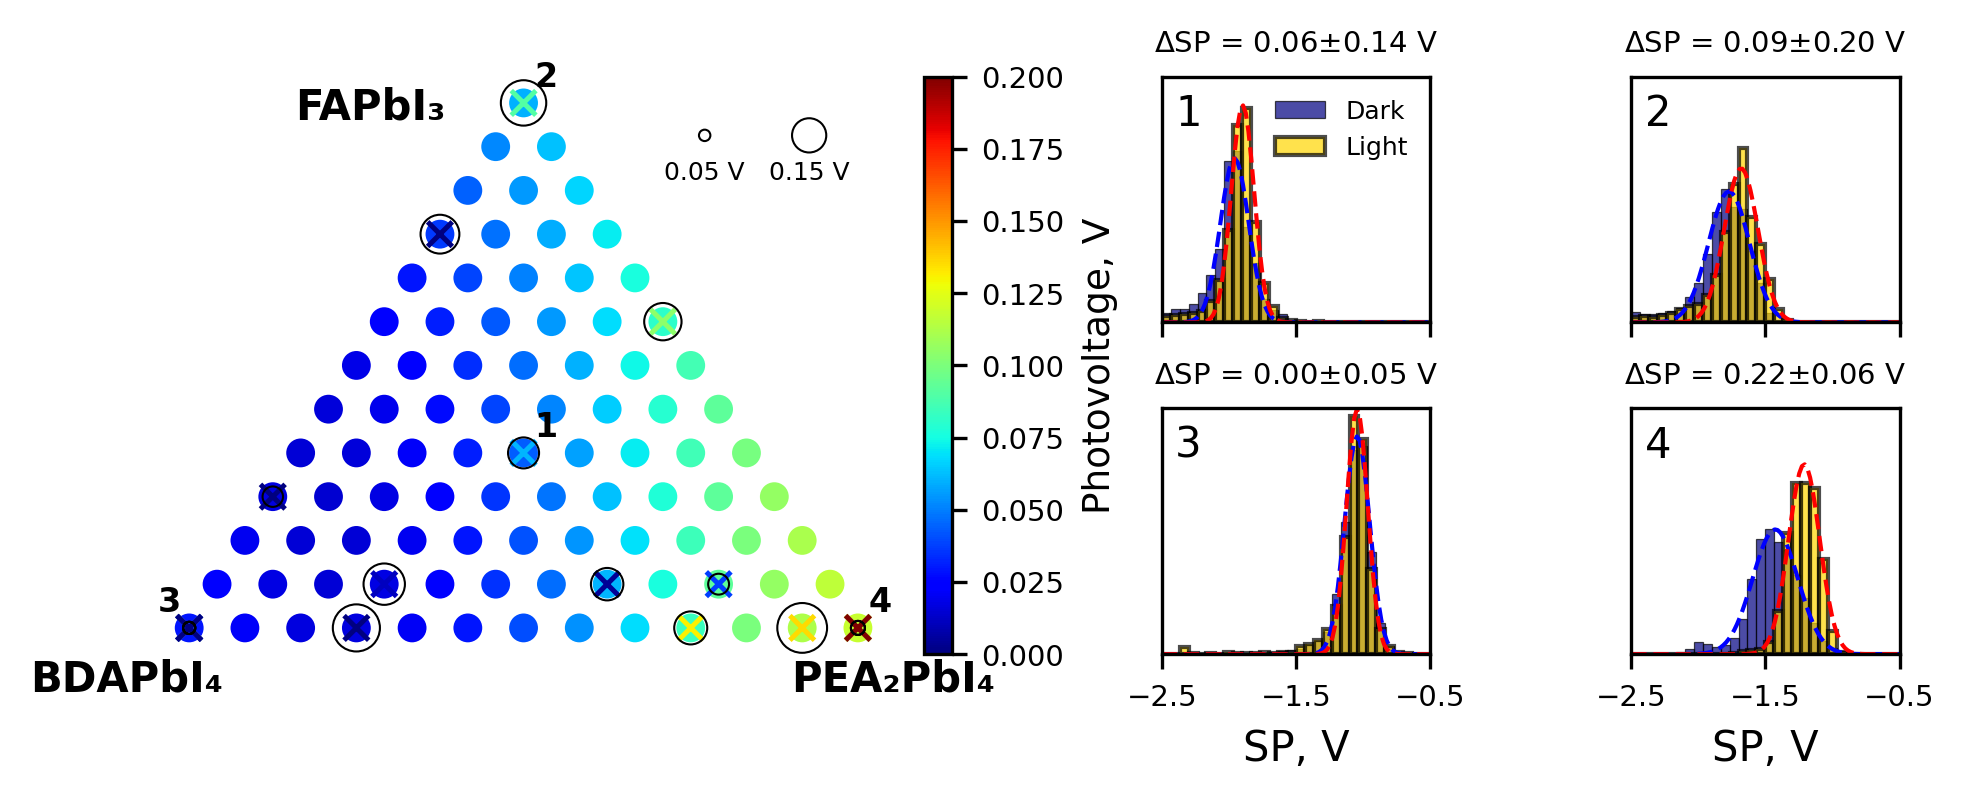

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pred = np.array([_mean, _var])



# -----------------------------
# helper
# -----------------------------
def gaussian1(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# -----------------------------
# choose 4 measured points
# -----------------------------
idx_list = [1, 3, -2, -1]   # change to the 4 points you want to show

# histogram range
range_min = -2.5
range_max = -.5

# -----------------------------
# figure layout
# -----------------------------
fig = plt.figure(figsize=(7.5, 2.5), dpi=300)
gs = fig.add_gridspec(2, 3, width_ratios=[3, 1, 1], wspace=0.45, hspace=0.35)

# left large axis
ax_pred = fig.add_subplot(gs[:, 0])

# right 2x2 histogram axes
ax_hist = [
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

# -----------------------------
# left panel: GP prediction
# -----------------------------
im0 = ax_pred.scatter(*X.T, c=pred[0], vmin=0, vmax=0.2, cmap='jet', s=35)

# overlay training points
ax_pred.scatter(
    *X_train[1:].T,
    marker='x',
    c=y_train_new[1:],
    vmin=0,
    vmax=0.2,
    cmap='jet',
    s=35,
    linewidths=1.2
)

# error rings: radius ~ dSP error (between-droplet std for repeated
# compositions, within-droplet sigma otherwise)
err_size_scale = 3000   # tune ring size here
ax_pred.scatter(
    *X_train[1:].T,
    s=err_size_scale * err_dsp[1:]**2,
    facecolors='none',
    edgecolors='k',
    linewidths=0.5,
    zorder=2
)

# reference rings (size legend)
for e_ref, x_ref in zip([0.05, 0.15], [0.78, 0.93]):
    ax_pred.scatter(
        [x_ref], [0.78],
        s=err_size_scale * e_ref**2,
        facecolors='none',
        edgecolors='k',
        linewidths=0.5
    )
    ax_pred.text(x_ref, 0.71, f'{e_ref:.2f} V', ha='center', fontsize=6)

cbar = fig.colorbar(im0, ax=ax_pred, fraction=0.046, pad=0.04)
cbar.set_label('Photovoltage, V', fontsize=9)
cbar.ax.tick_params(labelsize=7)

for _ in [ax_pred]:
  _.text(-.05, -0.1, "BDAPbI₄", ha='center', fontsize=10, fontweight='bold')
  _.text(1.05, -0.1, "PEA₂PbI₄", ha='center', fontsize=10, fontweight='bold')
  _.text(0.3, np.sqrt(3)/2-0.06, "FAPbI₃", ha='center', fontsize=10, fontweight='bold')
  _.axis('off')

for j, ii in enumerate(idx_list, start=1):
    x_pt, y_pt = X_train[ii]
    print(ii, j)
    if j != 3:
      ax_pred.text(
          x_pt + 0.015, y_pt + 0.015, str(j),
          fontsize=8,
          fontweight='bold',
          color='black',
          ha='left',
          va='bottom'
      )
    else:
      ax_pred.text(
          x_pt - 0.045, y_pt + 0.015, str(j),
          fontsize=8,
          fontweight='bold',
          color='black',
          ha='left',
          va='bottom'
      )

# -----------------------------
# right panels: histograms
# -----------------------------
for k, ii in enumerate(idx_list):
    ax = ax_hist[k]
    ax.text(-2.4, 2800, s=k+1)
    ax.set_ylim(0,3500)

    # crop borders if needed
    dark_vals = dark_data[ii][10:-10, 10:-10].flatten()
    light_vals = light_data[ii][10:-10, 10:-10].flatten()

    # dark histogram
    counts_d, bin_e_d, _ = ax.hist(
        dark_vals,
        color='navy',
        edgecolor='black',
        alpha=0.7,
        bins=30,
        linewidth=.3,
        range=(range_min, range_max),
        label='Dark'
    )

    # fit dark
    bin_c_d = (bin_e_d[:-1] + bin_e_d[1:]) / 2
    try:
        opt_d, _ = curve_fit(
            gaussian1, bin_c_d, counts_d,
            p0=[counts_d.max(), np.mean(dark_vals), np.std(dark_vals)]
        )
        x_fit = np.linspace(bin_e_d[0], bin_e_d[-1], 100)
        y_fit_d = gaussian1(x_fit, *opt_d)
        ax.plot(x_fit, y_fit_d, '--', color='blue', lw=1)
        mu_d = opt_d[1]
    except:
        mu_d = np.mean(dark_vals)

    # light histogram
    counts_l, bin_e_l, _ = ax.hist(
        light_vals,
        color='gold',
        edgecolor='black',
        alpha=0.7,
        bins=30,
        range=(range_min, range_max),
        label='Light'
    )

    # fit light
    bin_c_l = (bin_e_l[:-1] + bin_e_l[1:]) / 2
    try:
        opt_l, _ = curve_fit(
            gaussian1, bin_c_l, counts_l,
            p0=[counts_l.max(), np.mean(light_vals), np.std(light_vals)]
        )
        x_fit = np.linspace(bin_e_l[0], bin_e_l[-1], 100)
        y_fit_l = gaussian1(x_fit, *opt_l)
        ax.plot(x_fit, y_fit_l, '--', color='red', lw=1)
        mu_l = opt_l[1]
    except:
        mu_l = np.mean(light_vals)

    #ax.text(-2, 500, s=f'$\Delta$SP = {mu_l-mu_d:.2f} V', fontsize=6)
    ax.set_title(f'$\Delta$SP = {abs(mu_l-mu_d):.2f}±{err_dsp[ii]:.2f} V', fontsize=7)


    ax.set_xlim(range_min, range_max)
    ax.set_xticks(np.linspace(range_min, range_max, 3))
    ax.tick_params(labelsize=7)

    if k in [2, 3]:
        ax.set_xlabel('SP, V', fontsize=10)

    if k in [0, 2]:
        #ax.set_ylabel('Count')
        ax.set_yticks([])

    if k in [1, 3]:
        #ax.set_ylabel('Count')
        ax.set_yticks([])

    if k in [0, 1]:
        #ax.set_ylabel('Count')
        ax.set_xticklabels([])

    if k == 0:
        ax.legend(frameon=False, fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig('photoKPFM_tern.jpg', dpi=300, bbox_inches='tight')

/tmp/ipykernel_6414/4038395630.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


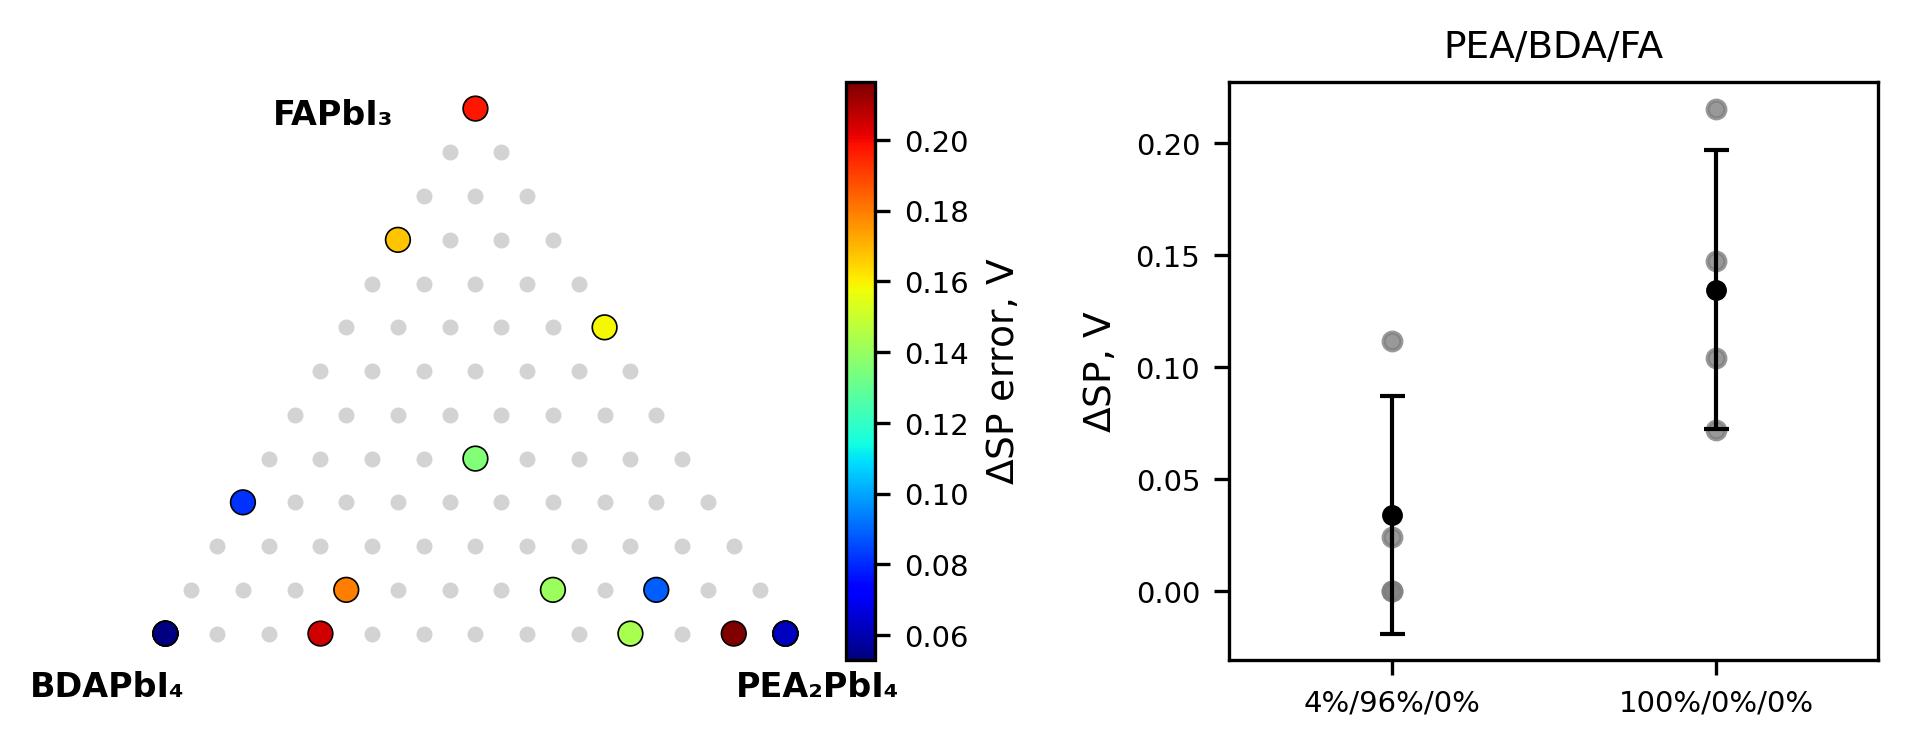

In [ ]:
#@title supplementary figure: error map + repeated compositions

# left: ternary map of the dSP error at every measured droplet
# right: droplet-to-droplet diversity for the repeated compositions
# same style/layout as the main draft figure

fig = plt.figure(figsize=(7.5, 2.5), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1], wspace=0.5)

ax_map = fig.add_subplot(gs[0, 0])
ax_rep = fig.add_subplot(gs[0, 1])

# -----------------------------
# left panel: error map
# -----------------------------
ax_map.scatter(*X.T, c='lightgray', s=8, zorder=1)

im = ax_map.scatter(
    *X_train.T,
    c=err_dsp,
    cmap='jet',
    s=35,
    edgecolors='black',
    linewidths=0.4,
    zorder=2
)

cbar = fig.colorbar(im, ax=ax_map, fraction=0.046, pad=0.04)
cbar.set_label(r'$\Delta$SP error, V', fontsize=9)
cbar.ax.tick_params(labelsize=7)

for _ in [ax_map]:
  _.text(-.05, -0.1, "BDAPbI₄", ha='center', fontsize=8, fontweight='bold')
  _.text(1.05, -0.1, "PEA₂PbI₄", ha='center', fontsize=8, fontweight='bold')
  _.text(0.3, np.sqrt(3)/2-0.06, "FAPbI₃", ha='center', fontsize=8, fontweight='bold')
  _.axis('off')

# -----------------------------
# right panel: repeats
# -----------------------------
k_plot = 0
xtick_labels = []

for g in range(len(uniq_comp)):
    members = np.where(inv_comp == g)[0]

    if len(members) < 2:
        continue

    # individual repeats
    ax_rep.scatter(
        np.full(len(members), k_plot),
        dsp[members],
        s=18,
        c='gray',
        alpha=0.8,
        zorder=2
    )

    # mean ± std (droplet-to-droplet diversity)
    ax_rep.errorbar(
        k_plot,
        np.mean(dsp[members]),
        yerr=np.std(dsp[members], ddof=1),
        fmt='o',
        ms=4,
        color='k',
        capsize=3,
        elinewidth=1,
        zorder=3
    )

    f = fracs[members[0]]
    xtick_labels.append(f'{f[0]:.0%}/{f[1]:.0%}/{f[2]:.0%}')
    k_plot += 1

if k_plot > 0:
    ax_rep.set_xticks(range(k_plot))
    ax_rep.set_xticklabels(xtick_labels, fontsize=7)
    ax_rep.set_xlim(-0.5, k_plot - 0.5)
else:
    ax_rep.text(0.5, 0.5, 'no repeated compositions',
                ha='center', va='center', transform=ax_rep.transAxes, fontsize=8)

ax_rep.set_title('PEA/BDA/FA', fontsize=9)
ax_rep.set_ylabel(r'$\Delta$SP, V', fontsize=9)
ax_rep.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

fig.savefig('photoKPFM_tern_supp.jpg', dpi=300, bbox_inches='tight')


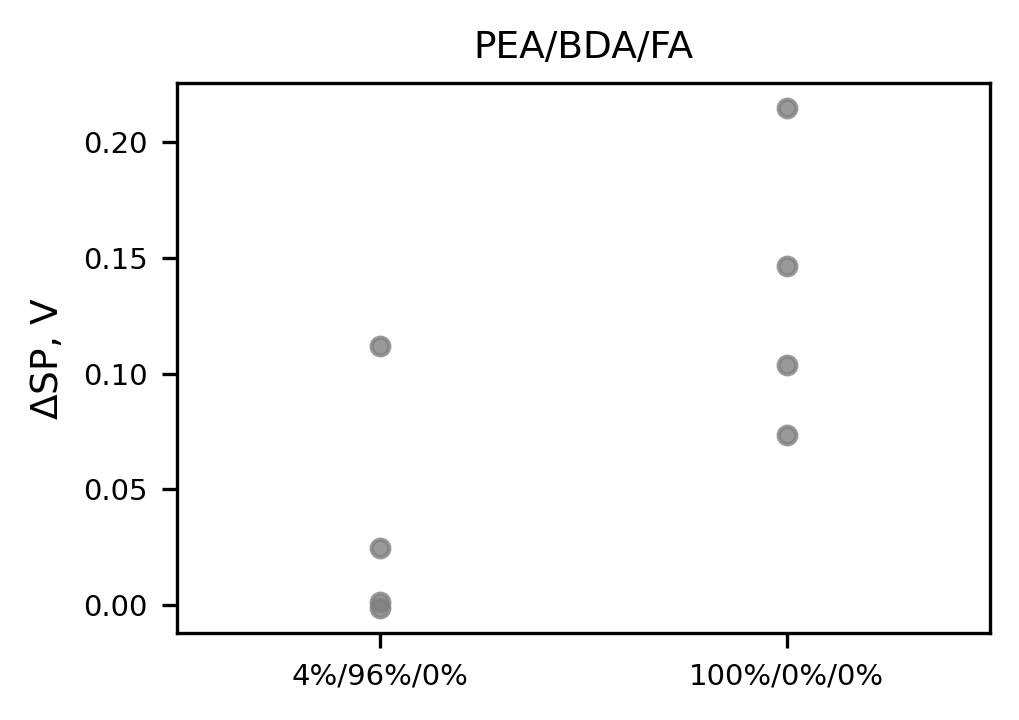

In [ ]:
#@title supplementary figure: error map + repeated compositions

# left: ternary map of the dSP error at every measured droplet
# right: droplet-to-droplet diversity for the repeated compositions
# same style/layout as the main draft figure

fig = plt.figure(figsize=(3.5, 2.5), dpi=300)
# gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1], wspace=0.5)

# ax_map = fig.add_subplot(gs[0, 0])
# ax_rep = fig.add_subplot(gs[0, 1])

# -----------------------------
# left panel: error map
# -----------------------------
# plt.scatter(*X.T, c='lightgray', s=8, zorder=1)

# im = plt.scatter(
#     *X_train.T,
#     c=err_dsp,
#     cmap='jet',
#     s=35,
#     edgecolors='black',
#     linewidths=0.4,
#     zorder=2
# )

# cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
# cbar.set_label(r'$\Delta$SP error, V', fontsize=9)
# cbar.ax.tick_params(labelsize=7)

# for _ in [ax_map]:
#   _.text(-.05, -0.1, "BDAPbI₄", ha='center', fontsize=8, fontweight='bold')
#   _.text(1.05, -0.1, "PEA₂PbI₄", ha='center', fontsize=8, fontweight='bold')
#   _.text(0.3, np.sqrt(3)/2-0.06, "FAPbI₃", ha='center', fontsize=8, fontweight='bold')
#   _.axis('off')

# -----------------------------
# right panel: repeats
# -----------------------------
k_plot = 0
xtick_labels = []

for g in range(len(uniq_comp)):
    members = np.where(inv_comp == g)[0]

    if len(members) < 2:
        continue

    # individual repeats
    plt.scatter(
        np.full(len(members), k_plot),
        dsp[members],
        s=18,
        c='gray',
        alpha=0.8,
        zorder=2
    )

    # # mean ± std (droplet-to-droplet diversity)
    # ax_rep.errorbar(
    #     k_plot,
    #     np.mean(dsp[members]),
    #     yerr=np.std(dsp[members], ddof=1),
    #     fmt='o',
    #     ms=4,
    #     color='k',
    #     capsize=3,
    #     elinewidth=1,
    #     zorder=3
    # )

    f = fracs[members[0]]
    xtick_labels.append(f'{f[0]:.0%}/{f[1]:.0%}/{f[2]:.0%}')
    k_plot += 1

if k_plot > 0:
    plt.xticks(range(k_plot), labels= xtick_labels)
    # plt.xtick(, fontsize=7)
    plt.xlim(-0.5, k_plot - 0.5)
else:
    plt.text(0.5, 0.5, 'no repeated compositions',
                ha='center', va='center', transform=ax_rep.transAxes, fontsize=8)

plt.title('PEA/BDA/FA', fontsize=9)
plt.ylabel(r'$\Delta$SP, V', fontsize=9)
plt.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

fig.savefig('photoKPFM_tern_supp.jpg', dpi=300, bbox_inches='tight')
